<a href="https://colab.research.google.com/github/fominfa/DL_test/blob/main/FirstNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import torch
import torch.nn as nn

In [3]:
n=5
m=3
linear_layer=nn.Linear(n, m, bias=True)
linear_layer

Linear(in_features=5, out_features=3, bias=True)

In [4]:
activation=nn.Sigmoid()
X_tensor=torch.tensor([
    [1, 2],
    [3, 4]
])
activation(X_tensor)

tensor([[0.7311, 0.8808],
        [0.9526, 0.9820]])

In [5]:
class Net(nn.Module):
    def __init__(self, in_dim=2, out_dim=2):
        super().__init__()
        self.lin=nn.Linear(in_dim, out_dim)
        self.act=nn.Sigmoid()
    def forward(self, x):
        y=self.lin(x)
        y=self.act(y)
        return y

In [6]:
net = Net(out_dim=1)
net

Net(
  (lin): Linear(in_features=2, out_features=1, bias=True)
  (act): Sigmoid()
)

In [7]:
net.lin.weight

Parameter containing:
tensor([[0.0678, 0.1937]], requires_grad=True)

In [8]:
import tqdm
from tqdm.auto import tqdm

In [9]:
def train(model, X, y, criterion, optimizer, num_epoch):
    losses = []
    for i in tqdm(range(num_epoch)):
        y_pred=model(X)
        loss=criterion(y_pred, y)
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
        losses.append(loss.item())
    return model, losses

In [10]:
loss=nn.BCELoss()
X = torch.randn((3, 2))
y = torch.FloatTensor([[0], [1], [0]])

In [14]:
optimizer=torch.optim.SGD(net.parameters(), lr=4e-3)
model, losses=train(net, X, y, loss, optimizer, 10000)
X

  0%|          | 0/10000 [00:00<?, ?it/s]

tensor([[ 0.6661,  2.2102],
        [ 1.2158, -0.0190],
        [-0.3245,  0.2841]])

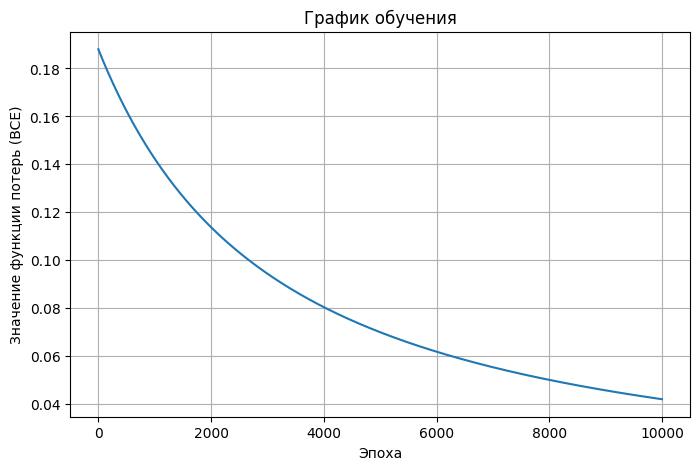

In [15]:
import matplotlib.pyplot as plt


plt.figure(figsize=(8, 5))
plt.plot(losses)
plt.xlabel('Эпоха')
plt.ylabel('Значение функции потерь (BCE)')
plt.title('График обучения')
plt.grid(True)
plt.show()